# Numerical Modeling of the 2-D Diffusion Equation (FTCS)

**Methods:** Finite differences (FTCS explicit scheme), NumPy, Matplotlib

### Overview
This notebook models the 2-D heat diffusion under periodic, Dirichlet, and Neumann boundary conditions.

----

This notebook develops diffusion models for a two-dimensional heat plate with flexible dimensions and initial conditions. The plate is assumed to have equal side lengths and equal spatial intervals in both directions.

\begin{align}
\frac{\partial{T}}{\partial{t}}-\alpha\left(\frac{\partial^2T}{\partial x^2}+\frac{\partial^2T}{\partial y^2}\right)=0
\end{align}

The diffusion behavior is investigated under three different boundary conditions:

1. Periodic or cyclic boundary conditions.

2. Dirichlet boundary conditions on all boundaries.

3. Neumann boundary conditions on all boundaries.

---

#### Describing the parameters for `dx`, `d`, `dt`, and `time_for_video`



In [13]:
d = 0.1
dx = 0.1
alpha = 0.25
dt = d*dx*dx/alpha
time_for_video = 10 #You can change here for longer video, but with additional running time too.

#### Import necessary library and Create functions to easily plot the graph

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import Video
from PIL import Image
from IPython.display import Image as IPyImage

def visualize(data, vmin, vmax, time):
  fig = plt.figure()
  pixel_plot = plt.imshow(data, cmap='nipy_spectral', interpolation='nearest', vmin=vmin, vmax=vmax)
  plt.colorbar(pixel_plot)
  plt.title(f'Latest Time step: {time:.5f}')
  plt.ylabel('Y-axis')
  plt.xlabel('X-axis')
  plt.show()

import os
os.makedirs("frames", exist_ok=True)

def frame_animation(data, vmin, vmax, step):
  pixel_plot = plt.imshow(data, cmap='nipy_spectral', interpolation='nearest', vmin=vmin, vmax=vmax)
  plt.colorbar(pixel_plot)
  plt.title(f'Time step: {(step)*dt:.5f}')
  plt.xlabel('X-axis')
  plt.ylabel('Y-axis')
  plt.savefig(f"frames/frame_{step:05d}.png")
  plt.clf()

import glob
def clear_frames():
  for f in glob.glob("frames/*"):
    os.remove(f)

from tqdm import tqdm

### Periodic/Cyclic boundary conditions

Setting up the domain at `Time step = 0`.

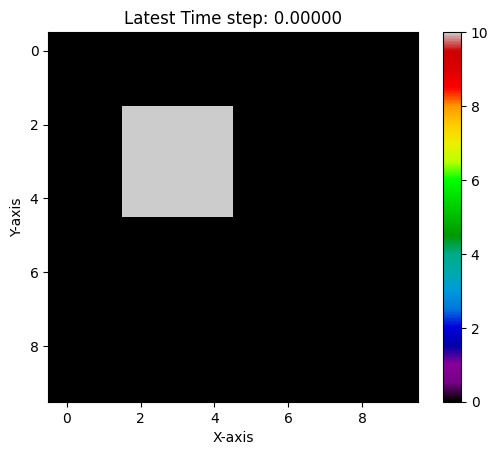

In [15]:
n = 0
grid_x = 10
grid_y = 10
T = np.zeros((grid_y, grid_x))
T[2:5, 2:5] = 10.0
visualize(T,vmin = 0, vmax = 10, time = n)

We can rewrite the 2D Heat Equation to get $T_{i,j}^{n+1}$ (`T` at next time step) using FTCS Method :
\begin{equation}
  \frac{\partial{T}}{\partial{t}}-\alpha\left(\frac{\partial^2T}{\partial x^2}+\frac{\partial^2T}{\partial y^2}\right)=0
\end{equation}

\begin{equation}
  \Rightarrow \frac{T_{i,j}^{n+1} - T_{i,j}^{n}}{\Delta t} = \alpha \left\{ \frac{T_{i+1,j}^{n} - 2T_{i,j}^{n} + T_{i-1,j}^{n}}{\Delta x^2} + \frac{T_{i,j+1}^{n} - 2T_{i,j}^{n} + T_{i,j-1}^{n}}{\Delta y^2} \right\}
\end{equation}

$$ \Delta x = \Delta y $$

\begin{equation}
  \Rightarrow \frac{T_{i,j}^{n+1} - T_{i,j}^{n}}{\Delta t} = \frac{\alpha}{\Delta x^2} \left\{ T_{i+1,j}^{n} - 2T_{i,j}^{n} + T_{i-1,j}^{n} + T_{i,j+1}^{n} - 2T_{i,j}^{n} + T_{i,j-1}^{n} \right\}
\end{equation}

\begin{equation}
  \Rightarrow T_{i,j}^{n+1} - T_{i,j}^{n} = \frac{\alpha \Delta t}{\Delta x^2} \left\{ T_{i+1,j}^{n} - 2T_{i,j}^{n} + T_{i-1,j}^{n} + T_{i,j+1}^{n} - 2T_{i,j}^{n} + T_{i,j-1}^{n} \right\}
\end{equation}

\begin{equation}
  \Rightarrow T_{i,j}^{n+1} = T_{i,j}^{n} + d \left\{ T_{i+1,j}^{n} - 2T_{i,j}^{n} + T_{i-1,j}^{n} + T_{i,j+1}^{n} - 2T_{i,j}^{n} + T_{i,j-1}^{n} \right\} ; d = \frac{\alpha \Delta t}{\Delta x^2}
\end{equation}

Which can be simplified and rewritten to the equation below :

\begin{equation}
  T_{i,j}^{n+1} = T_{i,j}^{n} + d \left\{ T_{i+1,j}^{n} + T_{i-1,j}^{n} + T_{i,j+1}^{n} + T_{i,j-1}^{n} - 4T_{i,j}^{n} \right\} \tag{Periodic/Cyclic Boundary Conditions Model}
\end{equation}

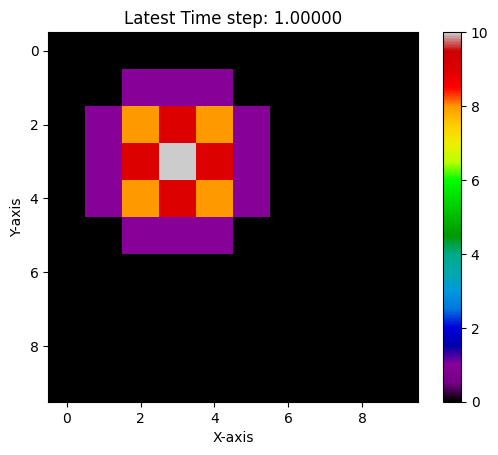

In [16]:
n = n + 1 #To show step order by the number of time we run this cell
T = T + d*(np.roll(T, -1, 0)+np.roll(T, 1, 0)+np.roll(T, -1, 1)+np.roll(T, 1, 1)-4.0*T)
visualize(T,vmin = 0, vmax = 10, time = n)

Using `for-loop` function in bigger domain to see the result at determined time interval.

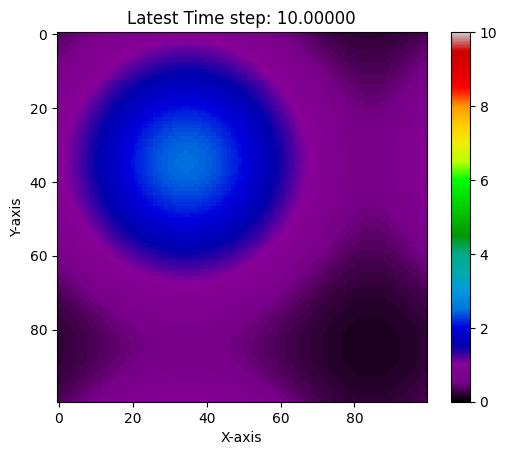

In [17]:
grid_x = 100
grid_y = 100
T = np.zeros((grid_y, grid_x))
T[20:50, 20:50] = 10

end_t = 10
n_total = end_t/dt

for n in range(0, int(n_total)+1) :
  T = T + d*(np.roll(T, -1, 0)+np.roll(T, 1, 0)+np.roll(T, -1, 1)+np.roll(T, 1, 1)-4.0*T)
visualize(T, vmin = 0, vmax = 10, time = (n+1)*dt)

#### For Video (change `end_t` (line 6) for change ending time)

In [18]:
grid_x = 100
grid_y = 100
T = np.zeros((grid_y, grid_x))
T[20:50, 20:50] = 10

end_t = time_for_video #Change the time here
n_total = end_t/dt
step_per_frames = 25

clear_frames()
pbar = tqdm(total=int(n_total), desc="Video Progress")

for n in range(0, int(n_total)+1) :
  if n % step_per_frames == 0:
    frame_animation(T, vmin = 0, vmax = 10, step = n//step_per_frames)
  T = T + d*(np.roll(T, -1, 0)+np.roll(T, 1, 0)+np.roll(T, -1, 1)+np.roll(T, 1, 1)-4.0*T)
  #print("Now getting : " + sorted(os.listdir("frames"))[n])
  pbar.update(1)
pbar.close()

files = sorted(glob.glob("frames/frame_*.png"))
imgs = [Image.open(f) for f in files]
if imgs:
  imgs[0].save("diffusion_periodic.gif", save_all=True,
             append_images=imgs[1:], duration=50, loop=0)

# from IPython.display import Image as IPyImage
# IPyImage(filename="diffusion_periodic.gif")   # renders inline in the notebook

# !ffmpeg -framerate 20 -i frames/frame_%05d.png -c:v libx264 -pix_fmt yuv420p Periodic_Cyclic.mp4
# Video("Periodic_Cyclic.mp4") #If video is not available try find the video in file name "Periodic_Cyclic.mp4" 

Video Progress:  98%|█████████▊| 983/1000 [01:30<00:01, 10.85it/s]
Video Progress: 2500it [00:08, 279.17it/s]                          


<Figure size 640x480 with 0 Axes>

![Diffusion under periodic boundary conditions](diffusion_periodic.gif)

In [19]:
clear_frames() #Clear frames folder manually

### Dirichlet boundary conditions

Setting up the domain at `Time step = 0` for Dirichlet boundary conditions.

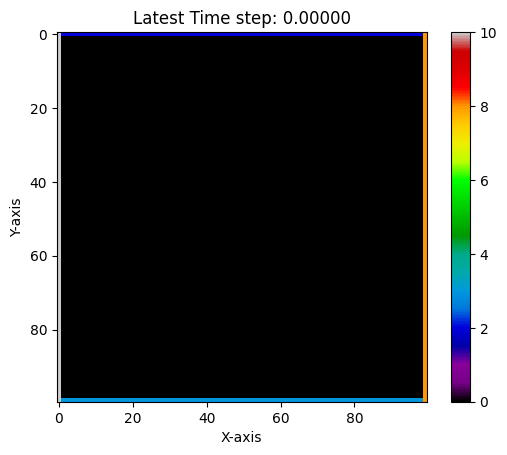

In [20]:
grid_x = 100
grid_y = 100
T = np.zeros((grid_y, grid_x))
T[0, :] = 2 #1st row of the matrix (Top of Domain) will have value of 2
T[-1, :] = 3 #last row of the matrix (Bottom of Domain) will have value of 3
T[:, 0] = 10 #1st column of the matrix (Left-side of Domain) will have value of 10
T[:, -1] = 8 #last column of the matrix (Right-side of Domain) will have value of 8
visualize(T, vmin = 0, vmax = 10, time = 0)

Using `for-loop` function with the source in the `for-loop` function to see the result at determined time interval in the case that source is fixed at the edge and continue getting into the domain.

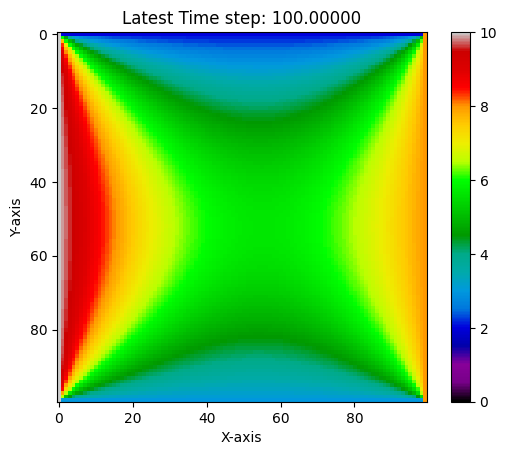

In [21]:
end_t = 100
n_total = end_t/dt

for n in range(0, int(n_total)+1) :
  T = T + d*(np.roll(T, -1, 0)+np.roll(T, 1, 0)+np.roll(T, -1, 1)+np.roll(T, 1, 1)-4.0*T)
  T[0, :] = 2
  T[-1, :] = 3
  T[:, 0] = 10
  T[:, -1] = 8
visualize(T, vmin = 0, vmax = 10, time = (n+1)*dt)

In this case we can still use `Periodic/Cyclic Boundary Conditions Model Equation` because the diffusion behavior of both condition inside the domain follows the same mathematical rule.

The only difference is :

- In the periodic case, the edges wrap around (e.g., left edge connects to right edge)

- In the Dirichlet case, the boundary values are fixed externally after each update

Since we already update the source in every loop. Therefore, we can use `Periodic/Cyclic Boundary Conditions Model Equation` for diffusion part.

#### For Video (change `end_t` (line 9) for change ending time)

In [22]:
grid_x = 100
grid_y = 100
T = np.zeros((grid_y, grid_x))
T[0, :] = 2
T[-1, :] = 3
T[:, 0] = 10
T[:, -1] = 8

end_t = 100 #time_for_video Change the time here (changed to 100 for better visualization)
n_total = end_t/dt
step_per_frames = 25

clear_frames()

total_frames = int(n_total) // step_per_frames + 1
pbar = tqdm(total=total_frames, desc="Video Progress")

for n in range(0, int(n_total)+1) :
  if n % step_per_frames == 0:
    frame_animation(T, vmin = 0, vmax = 10, step = n//step_per_frames)
    pbar.update(1)
  T = T + d*(np.roll(T, -1, 0)+np.roll(T, 1, 0)+np.roll(T, -1, 1)+np.roll(T, 1, 1)-4.0*T)
  T[0, :] = 2
  T[-1, :] = 3
  T[:, 0] = 10
  T[:, -1] = 8
pbar.close()

files = sorted(glob.glob("frames/frame_*.png"))
imgs = [Image.open(f) for f in files]
if imgs:
    imgs[0].save("diffusion_dirichlet.gif", save_all=True,
                 append_images=imgs[1:], duration=50, loop=0)

# IPyImage(filename="diffusion_dirichlet.gif")   # renders inline in the notebook

# !ffmpeg -framerate 120 -i frames/frame_%05d.png -c:v libx264 -pix_fmt yuv420p Dirichlet.mp4
# Video("Dirichlet.mp4") #If video is not available try find the video in file name "Dirichlet.mp4" 

Video Progress: 100%|██████████| 1000/1000 [01:32<00:00, 10.85it/s]


<Figure size 640x480 with 0 Axes>

![Diffusion under Dirichlet boundary conditions](diffusion_dirichlet.gif)

In [23]:
clear_frames() #Clear frames folder manually

### Neumann boundary condition (no flux)

#### Neumann boundary condition (no flux) along X-walls

This is similar to the above cases, but this time the Neumann boundary condition does not allow flux through the X-walls on both sides, which means diffusion behavior does not follow same mathematical rule as those we have done so far for those 2 edge we want to block the flux.

The difference here is that there are walls on both left and right sides of the domain. Hence, we need to separate the equation into 3 cases:

- Left-side of Domain ($1^{st}$ column of the matrix)

- Right-side of Domain (last column of the matrix)

- Else ($2^{nd}$ column of the matrix until the column before last)



Setting up the domain at `Time step = 0`.

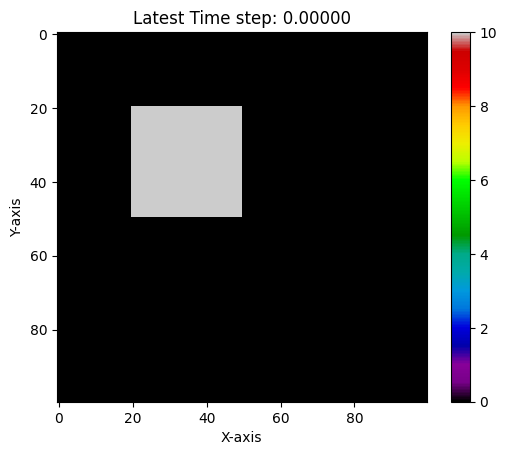

In [24]:
grid_x = 100
grid_y = 100
T = np.zeros((grid_y, grid_x))
T[20:50, 20:50] = 10
T[:, 0] = T[:, 0] + d*(np.roll(T[:, 0], -1)+np.roll(T[:, 0], 1)+T[:, 1]+T[:, 1]-4*T[:,0]) #Does not effect anyway since the source is still inside the domain (Not reaching the edge yet)
T[:, -1] = T[:, -1] + d*(np.roll(T[:, -1], -1)+np.roll(T[:, -1], 1)+T[:, -2]+T[:, -2]-4*T[:, -1]) #Does not effect anyway since the source is still inside the domain (Not reaching the edge yet)

visualize(T, vmin = 0, vmax = 10, time = 0)

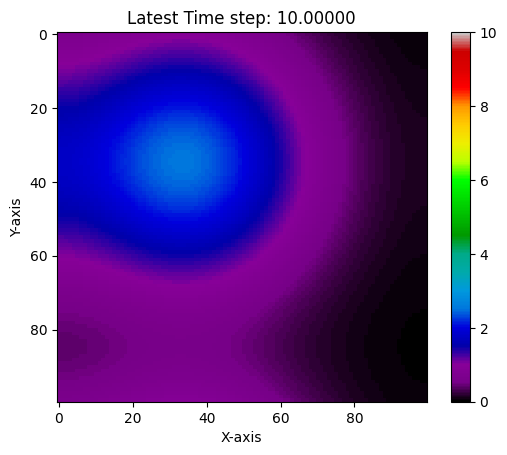

In [25]:
end_t = 10
n_total = end_t/dt

for n in range(0, int(n_total)+1) :
  T[:, 0] = T[:, 0] + d*(np.roll(T[:, 0], -1)+np.roll(T[:, 0], 1)+T[:, 1]+T[:, 1]-4*T[:,0]) #T[:, 1] instead of T[:, -2] because bounce back
  T[:, -1] = T[:, -1] + d*(np.roll(T[:, -1], -1)+np.roll(T[:, -1], 1)+T[:, -2]+T[:, -2]-4*T[:, -1]) #T[:, -2] instead of T[:, 1] because bounce back
  T[:, 1:-1] = T[:, 1:-1] + d*(np.roll(T[:, 1:-1], -1, 0)+np.roll(T[:, 1:-1], 1, 0)+T[:, 2:]+T[:, 0:-2]-4*T[:,1:-1]) #Middle part
visualize(T, vmin = 0, vmax = 10, time = (n+1)*dt)

In periodic boundaries, values at one edge continue to the other side. But with this Neumann conditions (no-flux through X-walls), what's supposed to diffuse out at the edge is instead reflected back into the domain. So instead of letting the value pass through and go to the opposite side, we make it bounce back i.e. doubling its effect inward and ensuring nothing escapes the X-walls boundaries.

#### For Video (change `end_t` (line 6) for change ending time)

In [26]:
grid_x = 100
grid_y = 100
T = np.zeros((grid_y, grid_x))
T[20:50, 20:50] = 10

end_t = time_for_video #Change the time here
n_total = end_t/dt
step_per_frames = 25

clear_frames()

total_frames = int(n_total) // step_per_frames + 1
pbar = tqdm(total=total_frames, desc="Video Progress")

for n in range(0, int(n_total)+1) :
  if n % step_per_frames == 0:
    frame_animation(T, vmin = 0, vmax = 10, step = n//step_per_frames)
    pbar.update(1)
  T[:, 0] = T[:, 0] + d*(np.roll(T[:, 0], -1)+np.roll(T[:, 0], 1)+T[:, 1]+T[:, 1]-4*T[:,0])
  T[:, -1] = T[:, -1] + d*(np.roll(T[:, -1], -1)+np.roll(T[:, -1], 1)+T[:, -2]+T[:, -2]-4*T[:, -1])
  T[:, 1:-1] = T[:, 1:-1] + d*(np.roll(T[:, 1:-1], -1, 0)+np.roll(T[:, 1:-1], 1, 0)+T[:, 2:]+T[:, 0:-2]-4*T[:,1:-1])

pbar.close()

files = sorted(glob.glob("frames/frame_*.png"))
imgs = [Image.open(f) for f in files]
if imgs:
    imgs[0].save("diffusion_neumann_Xwalls.gif", save_all=True,
                 append_images=imgs[1:], duration=50, loop=0)

# IPyImage(filename="diffusion_neumann_Xwalls.gif")   # renders inline in the notebook

# !ffmpeg -framerate 20 -i frames/frame_%05d.png -c:v libx264 -pix_fmt yuv420p Neumann_Xwalls.mp4
# Video("Neumann_Xwalls.mp4") #If video is not available try find the video in file name "Neumann_Xwalls.mp4" 

Video Progress: 100%|██████████| 100/100 [00:09<00:00, 10.69it/s]


<Figure size 640x480 with 0 Axes>

![Diffusion, Neumann (no-flux) along X-walls](diffusion_neumann_Xwalls.gif)

In [27]:
clear_frames() #Clear frames folder manually

#### Neumann boundary condition (no flux) along Y-walls

Similar to the Neumann boundary condition (no flux) along the X-walls, we will do the same thing as before, but change from columns to rows.

The difference here is that there are walls on both top and bottom edges of the domain. Hence, we need to separate the equation into 3 cases:

- Top-edge of Domain ($1^{st}$ row of the matrix)

- Bottom-edge of Domain (last row of the matrix)

- Else ($2^{nd}$ row of the matrix until the row before last)


Setting up the domain at `Time step = 0`.

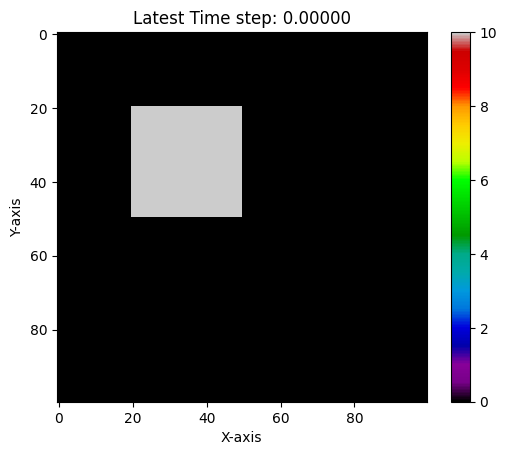

In [28]:
grid_x = 100
grid_y = 100
T = np.zeros((grid_y, grid_x))
T[20:50, 20:50] = 10
T[0, :] = T[0, :] + d*(np.roll(T[0, :], -1)+np.roll(T[0, :], 1)+T[1, :]+T[1, :]-4*T[0, :]) #Does not effect anyway since the source is still inside the domain (Not reaching the edge yet)
T[-1, :] = T[-1, :] + d*(np.roll(T[-1, :], -1)+np.roll(T[-1, :], 1)+T[-2, :]+T[-2, :]-4*T[-1, :]) #Does not effect anyway since the source is still inside the domain (Not reaching the edge yet)

visualize(T, vmin = 0, vmax = 10, time = 0)

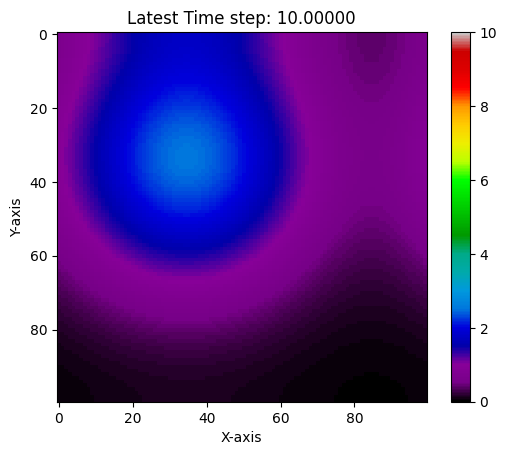

In [29]:
end_t = 10
n_total = end_t/dt

for n in range(0, int(n_total)+1) :
  T[0, :] = T[0, :] + d*(np.roll(T[0, :], -1)+np.roll(T[0, :], 1)+T[1, :]+T[1, :]-4*T[0, :]) #T[1, :] instead of T[-2, :] because bounce back
  T[-1, :] = T[-1, :] + d*(np.roll(T[-1, :], -1)+np.roll(T[-1, :], 1)+T[-2, :]+T[-2, :]-4*T[-1, :]) #T[-2, :] instead of T[1, :] because bounce back
  T[1:-1, :] = T[1:-1, :] + d*(np.roll(T[1:-1, :], -1, 1)+np.roll(T[1:-1, :], 1, 1)+T[2:, :]+T[0:-2, :]-4*T[1:-1, :]) #Middle part
visualize(T, vmin = 0, vmax = 10, time = (n+1)*dt)

#### For Video (change `end_t` (line 6) for change ending time)

In [30]:
grid_x = 100
grid_y = 100
T = np.zeros((grid_y, grid_x))
T[20:50, 20:50] = 10

end_t = time_for_video #Change the time here
n_total = end_t/dt
step_per_frames = 25

clear_frames()

total_frames = int(n_total) // step_per_frames + 1
pbar = tqdm(total=total_frames, desc="Video Progress")

for n in range(0, int(n_total)+1) :
  if n % step_per_frames == 0:
    frame_animation(T, vmin = 0, vmax = 10, step = n//step_per_frames)
    pbar.update(1)
  T[0, :] = T[0, :] + d*(np.roll(T[0, :], -1)+np.roll(T[0, :], 1)+T[1, :]+T[1, :]-4*T[0, :])
  T[-1, :] = T[-1, :] + d*(np.roll(T[-1, :], -1)+np.roll(T[-1, :], 1)+T[-2, :]+T[-2, :]-4*T[-1, :])
  T[1:-1, :] = T[1:-1, :] + d*(np.roll(T[1:-1, :], -1, 1)+np.roll(T[1:-1, :], 1, 1)+T[2:, :]+T[0:-2, :]-4*T[1:-1, :])

pbar.close()

files = sorted(glob.glob("frames/frame_*.png"))
imgs = [Image.open(f) for f in files]
if imgs:
    imgs[0].save("diffusion_neumann_Ywalls.gif", save_all=True,
                 append_images=imgs[1:], duration=50, loop=0)

# IPyImage(filename="diffusion_neumann_Ywalls.gif")   # renders inline in the notebook

# !ffmpeg -framerate 20 -i frames/frame_%05d.png -c:v libx264 -pix_fmt yuv420p Neumann_Ywalls.mp4
# Video("Neumann_Ywalls.mp4") #If video is not available try find the video in file name "Neumann_Ywalls.mp4" 

Video Progress: 100%|██████████| 100/100 [00:09<00:00, 10.86it/s]


<Figure size 640x480 with 0 Axes>

![Diffusion, Neumann (no-flux) along Y-walls](diffusion_neumann_Ywalls.gif)

In [31]:
clear_frames() #Clear frames folder manually

#### Neumann boundary condition (no flux) along 4 sides of the walls

This is similar to 2 cases above, but this time the Neumann boundary condition does not allow flux through the all of the walls, which means diffusion behavior is the combination of Neumann boundary condition (no flux) along X-walls and Y-walls.

The difference here is that 4 of the corners will intercept. Hence, we need to separate the equation into 9 cases:

→ 4 of the edges (Bounce back)

- Left-side of Domain ($1^{st}$ column of the matrix except 2 of the corners `[0, 0]` and `[-1, 0]`)

- Right-side of Domain (last column of the matrix except 2 of the corners `[-1, 0]` and `[-1, -1]`)

- Top-edge of Domain ($1^{st}$ row of the matrix except 2 of the corners `[0, 0]` and `[0, -1]`)

- Bottom-edge of Domain (last row of the matrix except 2 of the corners `[-1, 0]` and `[-1, -1]`)

→ 4 of the corners (Bounce back in diagonal directions)

- Top-left corner `[0, 0]`

- Top-right corner `[0, -1]`

- Bottom-left corner `[-1, 0]`

- Bottom-right corner `[-1, -1]`

→ Middle Part

- Else ($2^{nd}$ column of the matrix until the column before last, excluding $1^{st}$ row and last row i.e. `[1:-1, 1:-1]`)

Setting up the domain at `Time step = 0`.

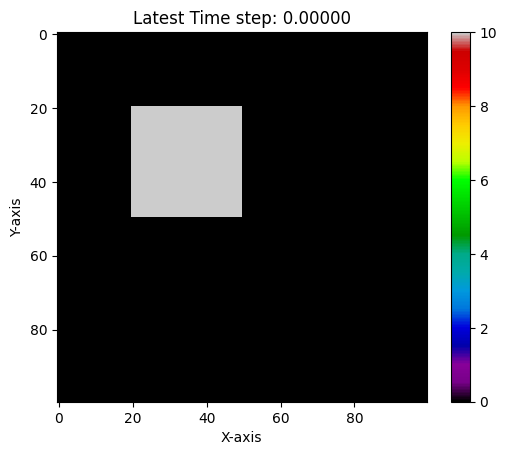

In [32]:
grid_x = 100
grid_y = 100
T = np.zeros((grid_y, grid_x))
T[20:50, 20:50] = 10

# 4 of the edges (Bounce back)
T[1:-1, 0] = T[1:-1, 0] + d*(T[2:, 0]+T[0:-2, 0]+T[1:-1, 1]+T[1:-1, 1]-4*T[1:-1,0]) #Does not effect anyway since the source is still inside the domain (Not reaching the edge yet)
T[1:-1, -1] = T[1:-1, -1] + d*(T[2:, -1]+T[0:-2, -1]+T[1:-1, -2]+T[1:-1, -2]-4*T[1:-1, -1]) #Does not effect anyway since the source is still inside the domain (Not reaching the edge yet)
T[0, 1:-1] = T[0, 1:-1] + d*(T[0, 2:]+T[0, 0:-2]+T[1, 1:-1]+T[1, 1:-1]-4*T[0, 1:-1]) #Does not effect anyway since the source is still inside the domain (Not reaching the edge yet)
T[-1, 1:-1] = T[-1, 1:-1] + d*(T[-1, 2:]+T[-1, 0:-2]+T[-2, 1:-1]+T[-2, 1:-1]-4*T[-1, 1:-1]) #Does not effect anyway since the source is still inside the domain (Not reaching the edge yet)

# 4 of the corners (Bounce back in diagonal directions)
T[0, 0] = T[0, 0] + d*(T[0, 1]+T[0, 1]+T[1, 0]+T[1, 0]-4*T[0, 0]) #Does not effect anyway since the source is still inside the domain (Not reaching the corner yet)
T[0, -1] = T[0, -1] + d*(T[0, -2]+T[0, -2]+T[1, -1]+T[1, -1]-4*T[0, -1]) #Does not effect anyway since the source is still inside the domain (Not reaching the corner yet)
T[-1, 0] = T[-1, 0] + d*(T[-1, 1]+T[-1, 1]+T[-2, 0]+T[-2, 0]-4*T[-1, 0]) #Does not effect anyway since the source is still inside the domain (Not reaching the corner yet)
T[-1, -1] = T[-1, -1] + d*(T[-1, -2]+T[-1, -2]+T[-2, -1]+T[-2, -1]-4*T[-1, -1]) #Does not effect anyway since the source is still inside the domain (Not reaching the corner yet)

#Middle Part (Not use yet for initial domain)
#T[1:-1, 1:-1] = T[1:-1, 1:-1] + d*(T[1:-1, 2:]+T[1:-1, 0:-2]+T[2:, 1:-1]+T[0:-2, 1:-1]-4*T[1:-1, 1:-1]) #Middle part
visualize(T, vmin = 0, vmax = 10, time = 0)

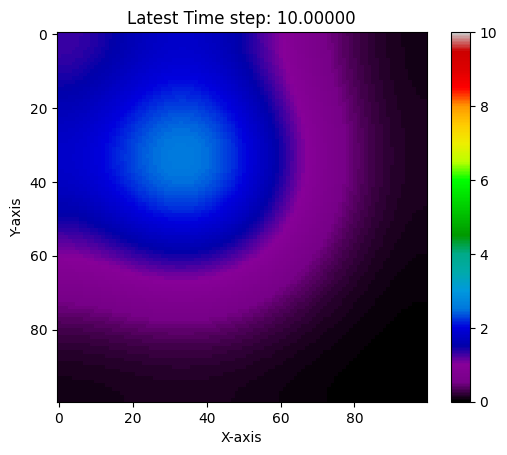

In [33]:
end_t = 10
n_total = end_t/dt

for n in range(0, int(n_total)+1) :
  # 4 of the edges (Bounce back)
  T[1:-1, 0] = T[1:-1, 0] + d*(T[2:, 0]+T[0:-2, 0]+T[1:-1, 1]+T[1:-1, 1]-4*T[1:-1,0]) #Left Edge
  T[1:-1, -1] = T[1:-1, -1] + d*(T[2:, -1]+T[0:-2, -1]+T[1:-1, -2]+T[1:-1, -2]-4*T[1:-1, -1]) #Right Edge
  T[0, 1:-1] = T[0, 1:-1] + d*(T[0, 2:]+T[0, 0:-2]+T[1, 1:-1]+T[1, 1:-1]-4*T[0, 1:-1]) #Top Edge
  T[-1, 1:-1] = T[-1, 1:-1] + d*(T[-1, 2:]+T[-1, 0:-2]+T[-2, 1:-1]+T[-2, 1:-1]-4*T[-1, 1:-1]) #Bottom Edge
  # 4 of the corners (Bounce back in diagonal directions)
  T[0, 0] = T[0, 0] + d*(T[0, 1]+T[0, 1]+T[1, 0]+T[1, 0]-4*T[0, 0]) #Top-left corner
  T[0, -1] = T[0, -1] + d*(T[0, -2]+T[0, -2]+T[1, -1]+T[1, -1]-4*T[0, -1]) #Top-right corner
  T[-1, 0] = T[-1, 0] + d*(T[-1, 1]+T[-1, 1]+T[-2, 0]+T[-2, 0]-4*T[-1, 0]) #Bottom-left corner
  T[-1, -1] = T[-1, -1] + d*(T[-1, -2]+T[-1, -2]+T[-2, -1]+T[-2, -1]-4*T[-1, -1]) #Bottom-right corner
  #Middle Part
  T[1:-1, 1:-1] = T[1:-1, 1:-1] + d*(T[1:-1, 2:]+T[1:-1, 0:-2]+T[2:, 1:-1]+T[0:-2, 1:-1]-4*T[1:-1, 1:-1])
visualize(T, vmin = 0, vmax = 10, time = (n+1)*dt)

As you can see from the graph above, we simply shift the matrix without using the `np.roll` function because we don't want it to go off the edges of the matrix through the other side of the domain. We want it to bounce back within the domain.

#### For Video (change `end_t` (line 6) for change ending time)

In [34]:
grid_x = 100
grid_y = 100
T = np.zeros((grid_y, grid_x))
T[20:50, 20:50] = 10

end_t = time_for_video #Change the time here
n_total = end_t/dt
step_per_frames = 25

clear_frames()

total_frames = int(n_total) // step_per_frames + 1
pbar = tqdm(total=total_frames, desc="Video Progress")

for n in range(0, int(n_total)+1) :
  if n % step_per_frames == 0:
    frame_animation(T, vmin = 0, vmax = 10, step = n//step_per_frames)
    pbar.update(1)

  T[1:-1, 0] = T[1:-1, 0] + d*(T[2:, 0]+T[0:-2, 0]+T[1:-1, 1]+T[1:-1, 1]-4*T[1:-1,0])
  T[1:-1, -1] = T[1:-1, -1] + d*(T[2:, -1]+T[0:-2, -1]+T[1:-1, -2]+T[1:-1, -2]-4*T[1:-1, -1])
  T[0, 1:-1] = T[0, 1:-1] + d*(T[0, 2:]+T[0, 0:-2]+T[1, 1:-1]+T[1, 1:-1]-4*T[0, 1:-1])
  T[-1, 1:-1] = T[-1, 1:-1] + d*(T[-1, 2:]+T[-1, 0:-2]+T[-2, 1:-1]+T[-2, 1:-1]-4*T[-1, 1:-1])

  T[0, 0] = T[0, 0] + d*(T[0, 1]+T[0, 1]+T[1, 0]+T[1, 0]-4*T[0, 0])
  T[0, -1] = T[0, -1] + d*(T[0, -2]+T[0, -2]+T[1, -1]+T[1, -1]-4*T[0, -1])
  T[-1, 0] = T[-1, 0] + d*(T[-1, 1]+T[-1, 1]+T[-2, 0]+T[-2, 0]-4*T[-1, 0])
  T[-1, -1] = T[-1, -1] + d*(T[-1, -2]+T[-1, -2]+T[-2, -1]+T[-2, -1]-4*T[-1, -1])

  T[1:-1, 1:-1] = T[1:-1, 1:-1] + d*(T[1:-1, 2:]+T[1:-1, 0:-2]+T[2:, 1:-1]+T[0:-2, 1:-1]-4*T[1:-1, 1:-1])

pbar.close()

files = sorted(glob.glob("frames/frame_*.png"))
imgs = [Image.open(f) for f in files]
if imgs:
    imgs[0].save("diffusion_neumann_Allwalls.gif", save_all=True,
                 append_images=imgs[1:], duration=50, loop=0)

# IPyImage(filename="diffusion_neumann_Allwalls.gif")   # renders inline in the notebook

# !ffmpeg -framerate 20 -i frames/frame_%05d.png -c:v libx264 -pix_fmt yuv420p Neumann_Allwalls.mp4
# Video("Neumann_Allwalls.mp4") #If video is not available try find the video in file name "Neumann_Allwalls.mp4" 

Video Progress: 100%|██████████| 100/100 [00:09<00:00, 11.04it/s]


<Figure size 640x480 with 0 Axes>

![Diffusion, Neumann (no-flux) on all walls](diffusion_neumann_Allwalls.gif)

In [35]:
clear_frames() #Clear frames folder manually

****Note**** on the video animation cells: Each boundary-condition section can generate animations in both `.gif` and `.mp4` formats. The GIF is used as the main embedded animation in this notebook. The `.mp4` generation cells, which require `ffmpeg`, are currently commented out and can be enabled if needed. These animations are optional, as the static plots above already show the main results.

The cell below deletes any generated `.mp4` files to allow for a clean re-run. Run it only when you want to remove the existing video files.


In [36]:
CLEAR_VIDEOS = False

if CLEAR_VIDEOS:
    for fi in glob.glob("*.mp4"):
        os.remove(fi)
        print(f"Deleted: {fi}")
else:
    print("Skipping video cleanup (set CLEAR_VIDEOS = True to enable).")

Skipping video cleanup (set CLEAR_VIDEOS = True to enable).
